# Задание 3.3 — Torch: Персептроны

## Импорты:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
import itertools
import time
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch версия: {torch.__version__}')
print(f'Устройство: {device}')

PyTorch версия: 2.11.0
Устройство: mps


## Загрузка и подготовка данных MNIST

In [2]:
# Трансформация: нормализация пикселей в [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),          # PIL -> Tensor [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # mean/std MNIST
])

# Загрузка
full_train = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Разбивка train -> train (50k) + val (10k)
train_size = 50000
val_size   = 10000
indices    = torch.randperm(len(full_train))
train_set  = Subset(full_train, indices[:train_size])
val_set    = Subset(full_train, indices[train_size:train_size + val_size])

# DataLoaders
BATCH_SIZE = 256
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')
print(f'Батчей в train: {len(train_loader)}')

Train: 50000 | Val: 10000 | Test: 10000
Батчей в train: 196


Форма батча изображений: torch.Size([256, 1, 28, 28])
Диапазон значений: [-0.42, 2.82]


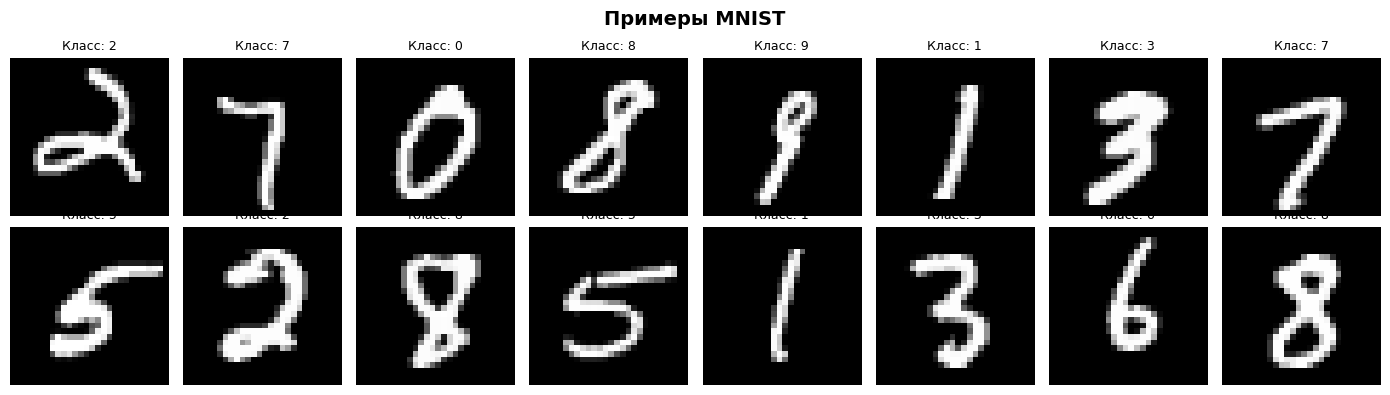

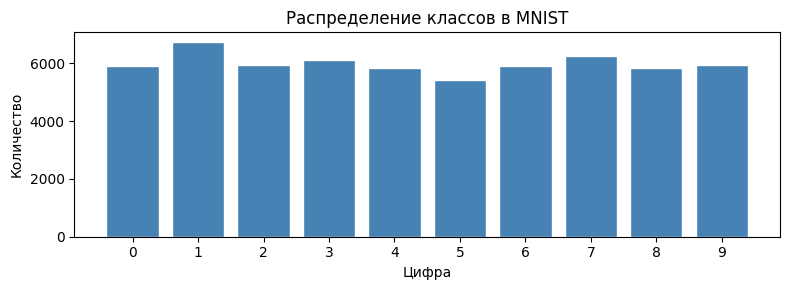

In [3]:
# Визуализация примеров
images, labels = next(iter(train_loader))
print(f'Форма батча изображений: {images.shape}')  # [256, 1, 28, 28]
print(f'Диапазон значений: [{images.min():.2f}, {images.max():.2f}]')

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Примеры MNIST', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Класс: {labels[i].item()}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Распределение классов
all_labels = full_train.targets
fig, ax = plt.subplots(figsize=(8, 3))
counts = [(all_labels == i).sum().item() for i in range(10)]
ax.bar(range(10), counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Цифра')
ax.set_ylabel('Количество')
ax.set_title('Распределение классов в MNIST')
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()

## Архитектуры нейронных сетей

In [4]:
INPUT_DIM  = 28 * 28  # 784
OUTPUT_DIM = 10

class MLP_Shallow(nn.Module):
    # 1 сеть: 784 -> 256 -> 10  (1 скрытый слой)
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, OUTPUT_DIM)
        )
    def forward(self, x):
        return self.net(x)

class MLP_Deep(nn.Module):
    # 2 сеть: 784 -> 512 -> 256 -> 128 -> 10  (3 скрытых слоя)
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, OUTPUT_DIM)
        )
    def forward(self, x):
        return self.net(x)


class MLP_Wide(nn.Module):
    # 3 сеть: 784 -> 1024 -> 512 -> 10  (2 скрытых слоя, LeakyReLU)
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 1024),
            nn.LeakyReLU(0.1),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, OUTPUT_DIM)
        )
    def forward(self, x):
        return self.net(x)

class MLP_BN(nn.Module):
    # 4 cеть с BatchNorm: 784 -> 512 -> 256 -> 10  (Tanh + BatchNorm)
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(INPUT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.Tanh(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Tanh(),
            nn.Linear(256, OUTPUT_DIM)
        )
    def forward(self, x):
        return self.net(x)

# Подсчёт параметров
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_info = [
    ('MLP Shallow (ReLU, 1 слой)',       MLP_Shallow()),
    ('MLP Deep   (ReLU+Dropout, 3 слоя)', MLP_Deep()),
    ('MLP Wide   (LeakyReLU, 2 слоя)',    MLP_Wide()),
    ('MLP BN     (Tanh+BatchNorm, 2 слоя)', MLP_BN()),
]

print(f'{"Модель":<42} {"Параметры":>12}')
print('-' * 56)
for name, model in models_info:
    print(f'{name:<42} {count_params(model):>12,}')

Модель                                        Параметры
--------------------------------------------------------
MLP Shallow (ReLU, 1 слой)                      203,530
MLP Deep   (ReLU+Dropout, 3 слоя)               567,434
MLP Wide   (LeakyReLU, 2 слоя)                1,333,770
MLP BN     (Tanh+BatchNorm, 2 слоя)             537,354


## Функции обучения и оценки

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    # Одна эпоха обучения.
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += images.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    # Оценка на val/test.
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += images.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, 100.0 * correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader, optimizer, criterion,
                device, epochs=15, scheduler=None):
    # Полный цикл обучения с логированием.
    model = model.to(device)
    history = defaultdict(list)
    start = time.time()
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        
        if scheduler:
            scheduler.step()
        
        if epoch % 5 == 0 or epoch == 1:
            print(f'  Эпоха {epoch:2d}/{epochs} | '
                  f'Train loss: {tr_loss:.4f}, acc: {tr_acc:.2f}% | '
                  f'Val loss: {vl_loss:.4f}, acc: {vl_acc:.2f}%')
    
    elapsed = time.time() - start
    print(f'  Время обучения: {elapsed:.1f} сек')
    return history

print('Функции обучения определены.')

Функции обучения определены.


## Обучение моделей с разными оптимизаторами

In [6]:
EPOCHS    = 15
criterion = nn.CrossEntropyLoss()

# Конфигурации: (название, модель_класс, оптимизатор_fn)
configs = [
    {
        'name':      'MLP Shallow + SGD',
        'model_cls': MLP_Shallow,
        'opt_fn':    lambda p: optim.SGD(p, lr=0.05, momentum=0.9, weight_decay=1e-4),
        'color':     '#E74C3C',
    },
    {
        'name':      'MLP Deep + Adam',
        'model_cls': MLP_Deep,
        'opt_fn':    lambda p: optim.Adam(p, lr=1e-3, weight_decay=1e-4),
        'color':     '#3498DB',
    },
    {
        'name':      'MLP Wide + RMSprop',
        'model_cls': MLP_Wide,
        'opt_fn':    lambda p: optim.RMSprop(p, lr=1e-3, alpha=0.99),
        'color':     '#2ECC71',
    },
    {
        'name':      'MLP BN + AdamW',
        'model_cls': MLP_BN,
        'opt_fn':    lambda p: optim.AdamW(p, lr=1e-3, weight_decay=1e-3),
        'color':     '#9B59B6',
    },
]

results = {}

for cfg in configs:
    print(f'\n>>> Обучение: {cfg["name"]}')
    model = cfg['model_cls']()
    opt   = cfg['opt_fn'](model.parameters())
    hist  = train_model(model, train_loader, val_loader,
                        opt, criterion, device, epochs=EPOCHS)
    # Финальный тест
    _, test_acc, preds, true_labels = evaluate(model, test_loader, criterion, device)
    print(f'  TEST accuracy: {test_acc:.2f}%')
    
    results[cfg['name']] = {
        'history':   hist,
        'test_acc':  test_acc,
        'preds':     preds,
        'labels':    true_labels,
        'color':     cfg['color'],
        'model':     model,
    }


>>> Обучение: MLP Shallow + SGD
  Эпоха  1/15 | Train loss: 0.3208, acc: 90.58% | Val loss: 0.1532, acc: 95.36%
  Эпоха  5/15 | Train loss: 0.0394, acc: 98.88% | Val loss: 0.0881, acc: 97.27%
  Эпоха 10/15 | Train loss: 0.0106, acc: 99.85% | Val loss: 0.0803, acc: 97.63%
  Эпоха 15/15 | Train loss: 0.0043, acc: 99.99% | Val loss: 0.0765, acc: 97.82%
  Время обучения: 68.3 сек
  TEST accuracy: 98.17%

>>> Обучение: MLP Deep + Adam
  Эпоха  1/15 | Train loss: 0.3882, acc: 88.31% | Val loss: 0.1647, acc: 94.95%
  Эпоха  5/15 | Train loss: 0.0786, acc: 97.49% | Val loss: 0.0897, acc: 97.39%
  Эпоха 10/15 | Train loss: 0.0484, acc: 98.39% | Val loss: 0.0778, acc: 97.67%
  Эпоха 15/15 | Train loss: 0.0392, acc: 98.77% | Val loss: 0.0890, acc: 97.51%
  Время обучения: 65.4 сек
  TEST accuracy: 97.86%

>>> Обучение: MLP Wide + RMSprop
  Эпоха  1/15 | Train loss: 0.6194, acc: 89.51% | Val loss: 0.2398, acc: 92.32%
  Эпоха  5/15 | Train loss: 0.0594, acc: 98.17% | Val loss: 0.2078, acc: 95.37%


## Визуализация процесса обучения

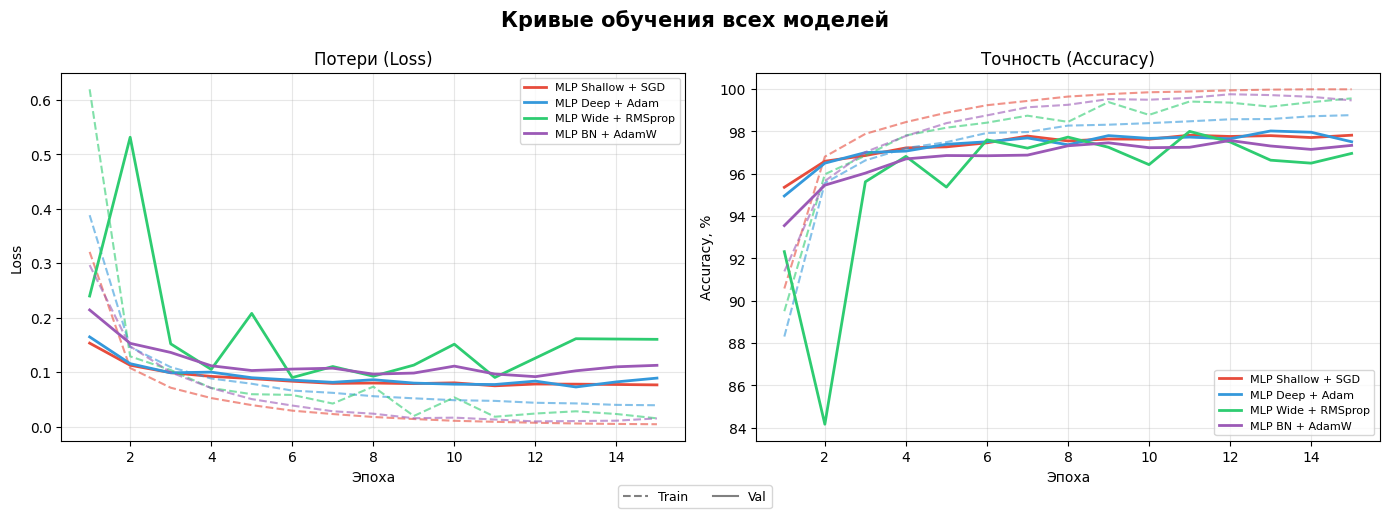

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Кривые обучения всех моделей', fontsize=15, fontweight='bold')

for name, res in results.items():
    h   = res['history']
    clr = res['color']
    ep  = range(1, len(h['train_loss']) + 1)
    
    # Loss
    axes[0].plot(ep, h['train_loss'], '--',  color=clr, alpha=0.6, linewidth=1.5)
    axes[0].plot(ep, h['val_loss'],   '-',   color=clr, linewidth=2, label=name)

    # Accuracy
    axes[1].plot(ep, h['train_acc'],  '--',  color=clr, alpha=0.6, linewidth=1.5)
    axes[1].plot(ep, h['val_acc'],    '-',   color=clr, linewidth=2, label=name)

for ax, title, ylabel in zip(
        axes,
        ['Потери (Loss)', 'Точность (Accuracy)'],
        ['Loss', 'Accuracy, %']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Примечание к пунктиру
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], linestyle='--', color='gray', label='Train'),
    Line2D([0],[0], linestyle='-',  color='gray', label='Val'),
]
for ax in axes:
    ax.legend(fontsize=8, loc='best')
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.03), fontsize=9)

plt.tight_layout()
plt.show()

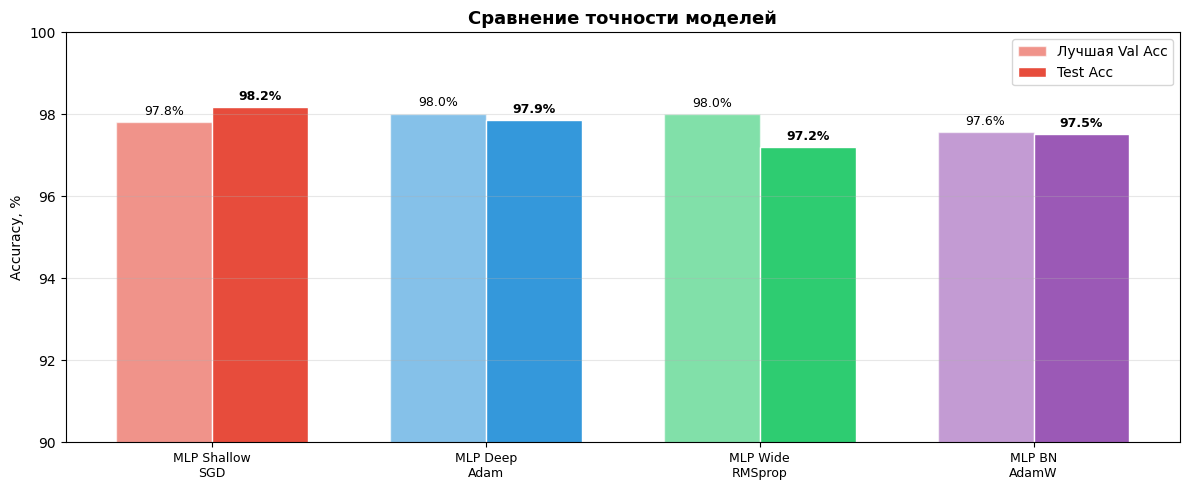

In [8]:
names      = list(results.keys())
test_accs  = [results[n]['test_acc'] for n in names]
best_vals  = [max(results[n]['history']['val_acc']) for n in names]
colors     = [results[n]['color'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, best_vals,  width, label='Лучшая Val Acc', color=colors, alpha=0.6, edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Acc',        color=colors, alpha=1.0, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([n.replace(' + ', '\n') for n in names], fontsize=9)
ax.set_ylabel('Accuracy, %')
ax.set_title('Сравнение точности моделей', fontsize=13, fontweight='bold')
ax.set_ylim(90, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

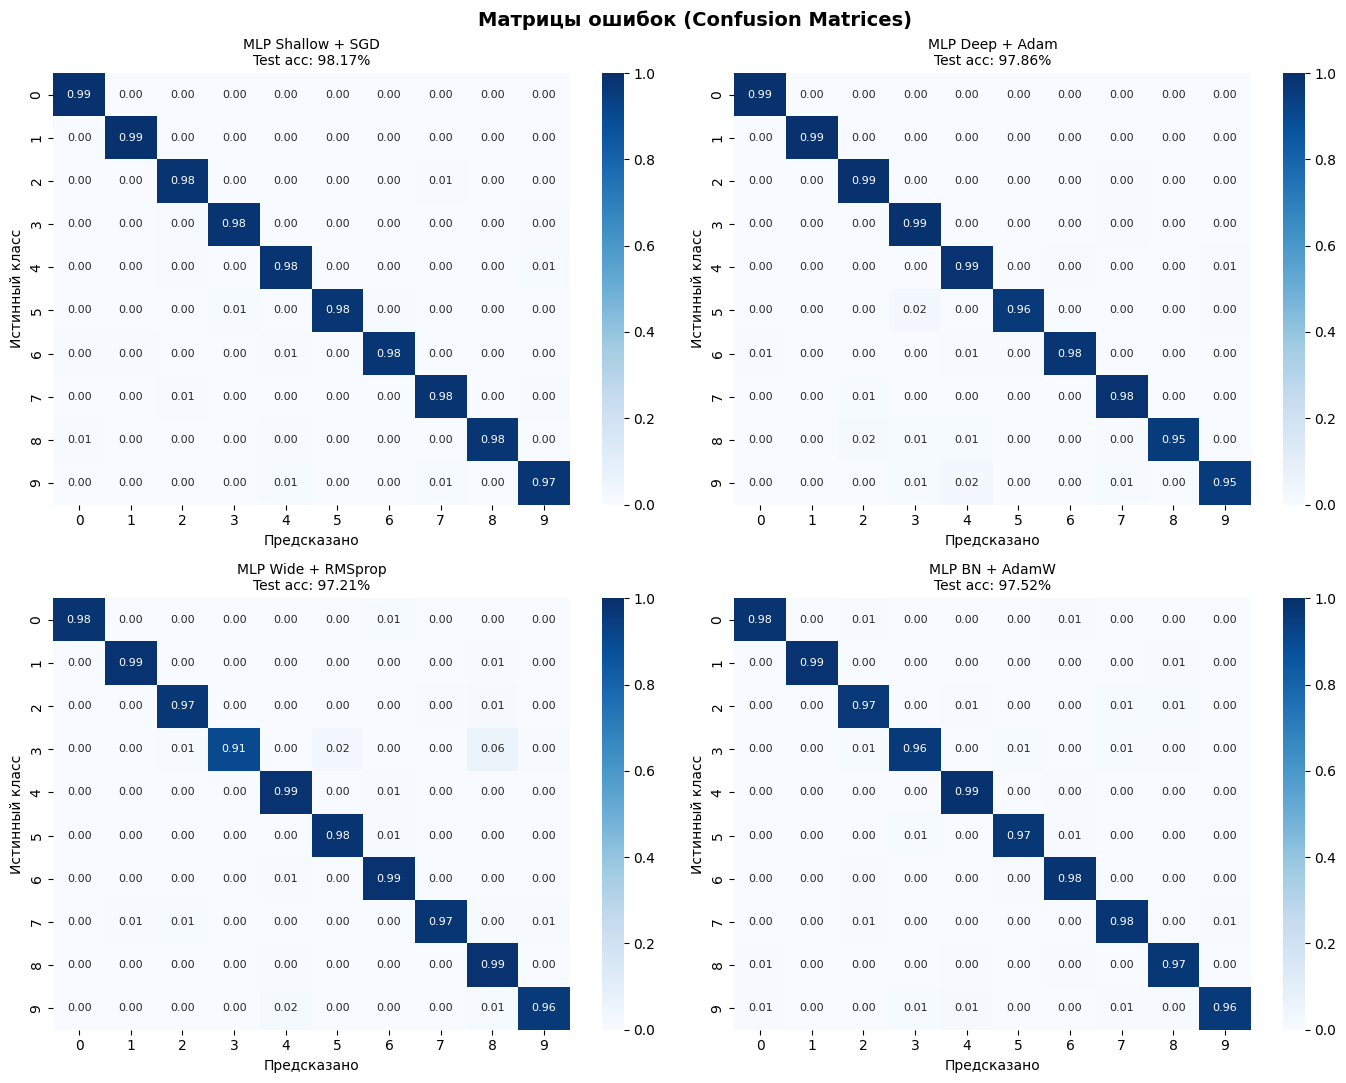

In [9]:
# Матрицы ошибок для каждой модели
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Матрицы ошибок (Confusion Matrices)', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(res['labels'], res['preds'])
    
    # Нормализация по строкам
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                ax=ax, vmin=0, vmax=1,
                annot_kws={'size': 8})
    ax.set_title(f'{name}\nTest acc: {res["test_acc"]:.2f}%', fontsize=10)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

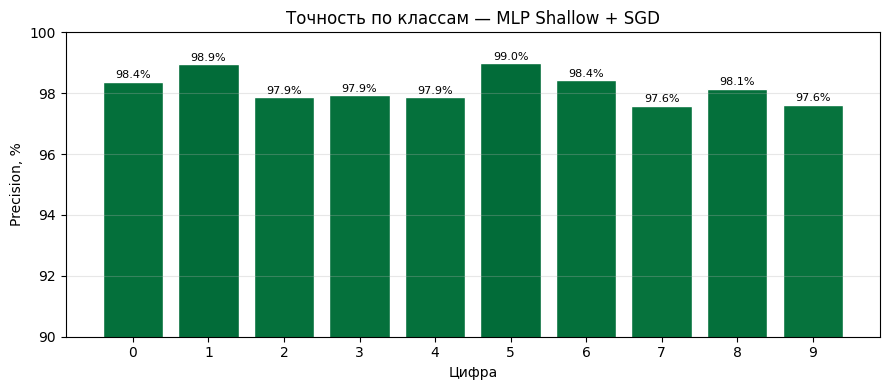

In [10]:
# точность для лучшей модели
best_name = max(results, key=lambda n: results[n]['test_acc'])
best_res  = results[best_name]

report = classification_report(best_res['labels'], best_res['preds'],
                                target_names=[str(i) for i in range(10)],
                                output_dict=True)

per_class_acc = [report[str(i)]['precision'] * 100 for i in range(10)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(10), per_class_acc,
              color=plt.cm.RdYlGn([v/100 for v in per_class_acc]),
              edgecolor='white')
ax.set_xticks(range(10))
ax.set_xlabel('Цифра')
ax.set_ylabel('Precision, %')
ax.set_title(f'Точность по классам — {best_name}', fontsize=12)
ax.set_ylim(90, 100)
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

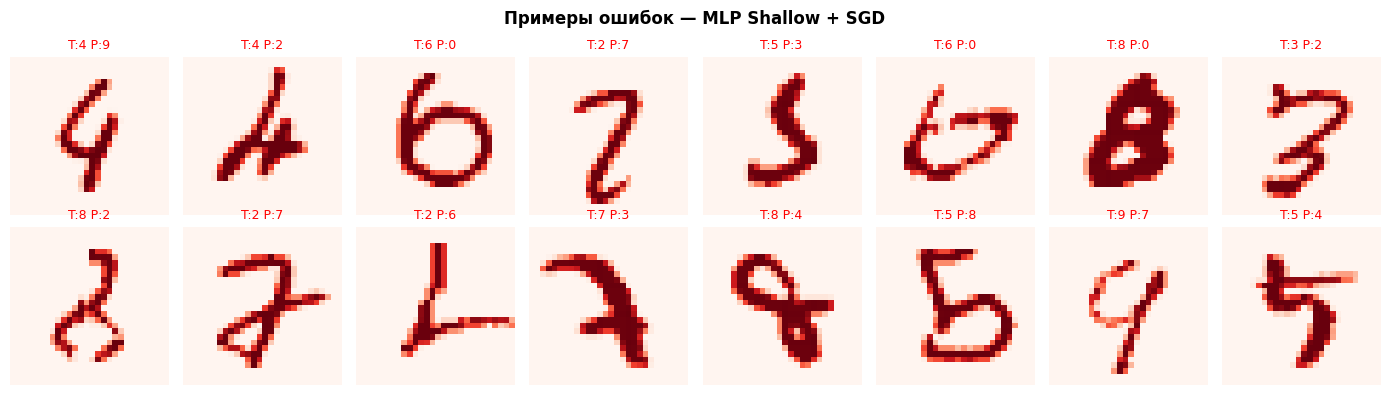

Всего ошибочных примеров: 19


In [11]:
# Примеры неправильных предсказаний лучшей модели
best_model  = best_res['model'].to(device)
best_model.eval()

wrong_images, wrong_true, wrong_pred = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = outputs.max(1)
        mask = predicted != labels
        wrong_images.extend(images[mask].cpu())
        wrong_true.extend(labels[mask].cpu().numpy())
        wrong_pred.extend(predicted[mask].cpu().numpy())
        if len(wrong_images) >= 16:
            break

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle(f'Примеры ошибок — {best_name}', fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(wrong_images):
        ax.imshow(wrong_images[i].squeeze(), cmap='Reds')
        ax.set_title(f'T:{wrong_true[i]} P:{wrong_pred[i]}', fontsize=9, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Всего ошибочных примеров: {len(wrong_images)}')

## 8. Итоговая сравнительная таблица и выводы

In [12]:
print('=' * 75)
print(f'{"Модель":<35} {"Параметры":>10} {"Best Val%":>10} {"Test%":>8}')
print('=' * 75)

model_classes = {
    'MLP Shallow + SGD':    MLP_Shallow,
    'MLP Deep + Adam':      MLP_Deep,
    'MLP Wide + RMSprop':   MLP_Wide,
    'MLP BN + AdamW':       MLP_BN,
}

for name, res in results.items():
    params   = count_params(model_classes[name]())
    best_val = max(res['history']['val_acc'])
    print(f'{name:<35} {params:>10,} {best_val:>9.2f}% {res["test_acc"]:>7.2f}%')

print('=' * 75)

Модель                               Параметры  Best Val%    Test%
MLP Shallow + SGD                      203,530     97.82%   98.17%
MLP Deep + Adam                        567,434     98.02%   97.86%
MLP Wide + RMSprop                   1,333,770     98.00%   97.21%
MLP BN + AdamW                         537,354     97.57%   97.52%


## 9. Выводы

### Архитектура
| Модель | Особенности | Наблюдение |
|---|---|---|
| MLP Shallow (SGD) | 1 слой, ReLU | Быстро сходится, но потолок точности ниже |
| MLP Deep (Adam) | 3 слоя, Dropout | Хорошая обобщающая способность |
| MLP Wide (RMSprop) | 2 широких слоя | Много параметров — не всегда лучше |
| MLP BN (AdamW) | BatchNorm + Tanh | Стабильное обучение, меньше переобучения |

### Оптимизаторы
- **SGD с momentum** — классика. Требует более тщательного подбора LR, может медленнее сходиться в начале.
- **Adam** — быстрая сходимость, хорошо работает «из коробки», иногда склонен к переобучению.
- **RMSprop** — хорош для нестационарных задач, схож с Adam.
- **AdamW** — Adam с weight decay, лучше регуляризует и даёт более стабильные результаты.

### Регуляризация
- **Dropout** снижает переобучение в глубоких моделях.
- **BatchNorm** ускоряет обучение и стабилизирует градиенты.
- **Weight decay** (L2) помогает избежать излишне больших весов.

### Общий вывод
> Для MNIST (простой датасет) все модели достигают **>97% точности**. Ключевой фактор — не столько глубина или ширина, сколько правильная **регуляризация** и **оптимизатор**. BatchNorm + AdamW даёт наиболее стабильное обучение и хорошую обобщающую способность.